# RHO and SOD simulation analysis

This notebook analyses the two topologies independently. It finds filling CSV files recursively, averages replicate curves belonging to the same case and growth folder, and reports hysteresis area, intrusion pressure, and extrusion pressure. Transition pressure is defined as the pressure of maximum absolute slope $|dF/dP|$ on the corresponding branch.

In [1]:
from pathlib import Path
from collections import defaultdict
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 300, 'figure.figsize': (11, 7),
    'font.size': 18, 'axes.titlesize': 18, 'axes.labelsize': 16,
    'xtick.labelsize': 18, 'ytick.labelsize': 18, 'legend.fontsize': 14,
    'axes.titleweight': 'bold', 'axes.labelweight': 'bold',
    'axes.linewidth': 1.4, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False
})
COLORS = ["#E24F5B", '#457B9D', '#2A9D8F', '#F4A261', '#7B2CBF',
          '#FF70A6', '#3A86FF', '#8AC926', '#FF9F1C', '#6D597A']

# Edit these paths if the result folders are elsewhere.
SOD_ROOTS = [Path('SOD'), Path('results_zif67_sensitivity')]
RHO_ROOTS = [Path('RHO'), Path('results_zif71_sensitivity')]

# Odd rolling-window size used before locating the maximum slope.
SMOOTHING_WINDOW = 101
COMMON_GRID_POINTS = 1500
FIGURE_DIR = Path('figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Shared analysis functions

In [2]:
def _replicate_base(stem):
    # Replicates are named ..._a.csv, ..._b.csv, etc.
    return re.sub(r'_[a-z]$', '', stem, flags=re.IGNORECASE)


def discover_groups(roots, patterns):
    groups = defaultdict(list)
    for root in map(Path, roots):
        if not root.exists():
            print(f'Skipping missing folder: {root}')
            continue
        files = sorted({p for pattern in patterns for p in root.glob(pattern)})
        for path in files:
            relative_parent = path.parent.relative_to(root)
            context = root.name if str(relative_parent) == '.' else f'{root.name}/{relative_parent.as_posix()}'
            key = f'{context}/{_replicate_base(path.stem)}'
            groups[key].append(path)
    return dict(sorted(groups.items()))


def read_filling_csv(path):
    frame = pd.read_csv(path)
    required = {'Pressure', 'Average_Filling'}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f'{path}: missing columns {sorted(missing)}')
    frame = frame[['Pressure', 'Average_Filling']].dropna().astype(float)
    if len(frame) < 4:
        raise ValueError(f'{path}: fewer than four valid rows')
    return frame.reset_index(drop=True)


def split_branches(frame):
    midpoint = len(frame) // 2
    intrusion = frame.iloc[:midpoint].copy()
    extrusion = frame.iloc[midpoint:].copy()
    return intrusion, extrusion


def prepare_branch(branch):
    # Average duplicate pressures and sort so interpolation is well-defined.
    return (branch.groupby('Pressure', as_index=False)['Average_Filling']
                  .mean().sort_values('Pressure').reset_index(drop=True))


def transition_pressure(branch, smoothing_window=SMOOTHING_WINDOW):
    branch = prepare_branch(branch)
    p = branch['Pressure'].to_numpy()
    f = branch['Average_Filling'].to_numpy()
    window = min(smoothing_window, len(f) if len(f) % 2 else len(f) - 1)
    window = max(window, 1)
    smooth = pd.Series(f).rolling(window, center=True, min_periods=1).mean().to_numpy()
    slope = np.gradient(smooth, p)
    edge = max(1, int(0.01 * len(p)))
    candidates = np.arange(edge, len(p) - edge) if len(p) > 2 * edge else np.arange(len(p))
    return float(p[candidates[np.argmax(np.abs(slope[candidates]))]])


def hysteresis_area(intrusion, extrusion, grid_points=COMMON_GRID_POINTS):
    intrusion, extrusion = prepare_branch(intrusion), prepare_branch(extrusion)
    lower = max(intrusion.Pressure.min(), extrusion.Pressure.min())
    upper = min(intrusion.Pressure.max(), extrusion.Pressure.max())
    grid = np.linspace(lower, upper, grid_points)
    f_in = np.interp(grid, intrusion.Pressure, intrusion.Average_Filling)
    f_ex = np.interp(grid, extrusion.Pressure, extrusion.Average_Filling)
    return float(np.trapz(np.abs(f_in - f_ex), grid))


def analyse_replicate(path):
    frame = read_filling_csv(path)
    intrusion, extrusion = split_branches(frame)
    return {
        'File': str(path),
        'Hysteresis': hysteresis_area(intrusion, extrusion),
        'Intrusion_Pressure': transition_pressure(intrusion),
        'Extrusion_Pressure': transition_pressure(extrusion),
    }


def analyse_groups(groups):
    replicate_rows = []
    for group, paths in groups.items():
        for path in paths:
            replicate_rows.append({'Group': group, **analyse_replicate(path)})
    replicate_df = pd.DataFrame(replicate_rows)
    if replicate_df.empty:
        return replicate_df, pd.DataFrame()
    metric_columns = ['Hysteresis', 'Intrusion_Pressure', 'Extrusion_Pressure']
    replicate_df['_Metric_Set'] = replicate_df[metric_columns].round(12).astype(str).agg('|'.join, axis=1)
    summary = (replicate_df.groupby('Group')
               .agg(N_Files=('File', 'size'),
                    N_Unique_Results=('_Metric_Set', 'nunique'),
                    Hysteresis_Mean=('Hysteresis', 'mean'),
                    Hysteresis_SD=('Hysteresis', 'std'),
                    Intrusion_Pressure_Mean=('Intrusion_Pressure', 'mean'),
                    Intrusion_Pressure_SD=('Intrusion_Pressure', 'std'),
                    Extrusion_Pressure_Mean=('Extrusion_Pressure', 'mean'),
                    Extrusion_Pressure_SD=('Extrusion_Pressure', 'std'))
               .reset_index())
    replicate_df = replicate_df.drop(columns='_Metric_Set')
    identical = summary.query('N_Files > 1 and N_Unique_Results == 1')
    for group in identical.Group:
        print(f'WARNING: all replicate metrics are identical in {group}; SD is zero.')
    return replicate_df, summary.fillna(0.0)


def averaged_branch(paths, branch_name, grid_points=COMMON_GRID_POINTS):
    branches = []
    for path in paths:
        branch = split_branches(read_filling_csv(path))[0 if branch_name == 'intrusion' else 1]
        branches.append(prepare_branch(branch))
    lower = max(branch.Pressure.min() for branch in branches)
    upper = min(branch.Pressure.max() for branch in branches)
    grid = np.linspace(lower, upper, grid_points)
    values = np.vstack([np.interp(grid, b.Pressure, b.Average_Filling) for b in branches])
    return grid, values.mean(axis=0), values.std(axis=0, ddof=1) if len(values) > 1 else np.zeros_like(grid)


def plot_averaged_loops(groups, title, selected_groups=None):
    selected = selected_groups or list(groups)
    fig, ax = plt.subplots(figsize=(12, 7))
    colors = [COLORS[i % len(COLORS)] for i in range(max(len(selected), 1))]
    for color, group in zip(colors, selected):
        paths = groups[group]
        p_in, mean_in, sd_in = averaged_branch(paths, 'intrusion')
        p_ex, mean_ex, sd_ex = averaged_branch(paths, 'extrusion')
        label = f'{group} (n={len(paths)})'
        ax.plot(p_in, mean_in, color=color, lw=4.2, ls='-', label=label)
        ax.plot(p_ex, mean_ex, color=color, lw=4.2, ls='--')
        ax.fill_between(p_in, mean_in - sd_in, mean_in + sd_in, color=color, alpha=.3)
        ax.fill_between(p_ex, mean_ex - sd_ex, mean_ex + sd_ex, color=color, alpha=.3)
    ax.set(xlabel='Pressure', ylabel='Average filling', title=title)
    ax.text(.02, .96, '—  Intrusion     - -  Extrusion', transform=ax.transAxes,
            va='top', fontsize=12, weight='bold')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
    fig.tight_layout()
    return fig, ax


def plot_metric_summary(summary, topology_name):
    if summary.empty:
        print(f'No {topology_name} results to plot.')
        return None
    metrics = [
        ('Hysteresis_Mean', 'Hysteresis_SD', 'Hysteresis area'),
        ('Intrusion_Pressure_Mean', 'Intrusion_Pressure_SD', 'Intrusion pressure'),
        ('Extrusion_Pressure_Mean', 'Extrusion_Pressure_SD', 'Extrusion pressure'),
    ]
    x = np.arange(len(summary))
    point_colors = [COLORS[i % len(COLORS)] for i in x]
    width = max(13, 0.45 * len(summary))
    fig, axes = plt.subplots(1, 3, figsize=(width, 5.8), sharex=True)
    for ax, (mean_col, sd_col, label) in zip(axes, metrics):
        means = summary[mean_col].to_numpy()
        errors = summary[sd_col].to_numpy()
        ax.plot(x, means, color='#6C757D', lw=2.2, alpha=.55, zorder=1)
        for xi, mean, error, color in zip(x, means, errors, point_colors):
            ax.errorbar(xi, mean, yerr=error, fmt='o', ms=10, mfc=color, mec='white',
                        mew=1.6, ecolor=color, elinewidth=2.5, capsize=5, capthick=2.5, zorder=3)
        ax.set_title(label, color='#263238', pad=12)
        ax.set_ylabel(label)
        ax.set_xticks([])
        ax.margins(x=.05)
    fig.suptitle(f'{topology_name} — mean ± SD across replicate files',
                 fontsize=20, fontweight='bold', y=1.03)
    fig.tight_layout(w_pad=2.2)
    return fig, axes

# Part 1 — SOD topology

Replicate files such as `cage_filling_data_a.csv` and `cage_filling_data_b.csv` are averaged only when they share the same result-case and growth directory.

In [3]:
sod_groups = discover_groups(SOD_ROOTS, patterns=['**/cage_filling_data*.csv'])
print(f'SOD groups: {len(sod_groups)}; files: {sum(map(len, sod_groups.values()))}')
for group, files in sod_groups.items():
    print(f'{len(files):3d}  {group}')

sod_replicates, sod_summary = analyse_groups(sod_groups)
display(sod_summary)

Skipping missing folder: results_zif67_sensitivity
SOD groups: 1; files: 10
 10  SOD/cage_filling_data


,Group,N_Files,N_Unique_Results,Hysteresis_Mean,Hysteresis_SD,Intrusion_Pressure_Mean,Intrusion_Pressure_SD,Extrusion_Pressure_Mean,Extrusion_Pressure_SD
0,SOD/cage_filling_data,10,5,1.561131,0.177845,28.499142,0.388529,23.586226,0.388157


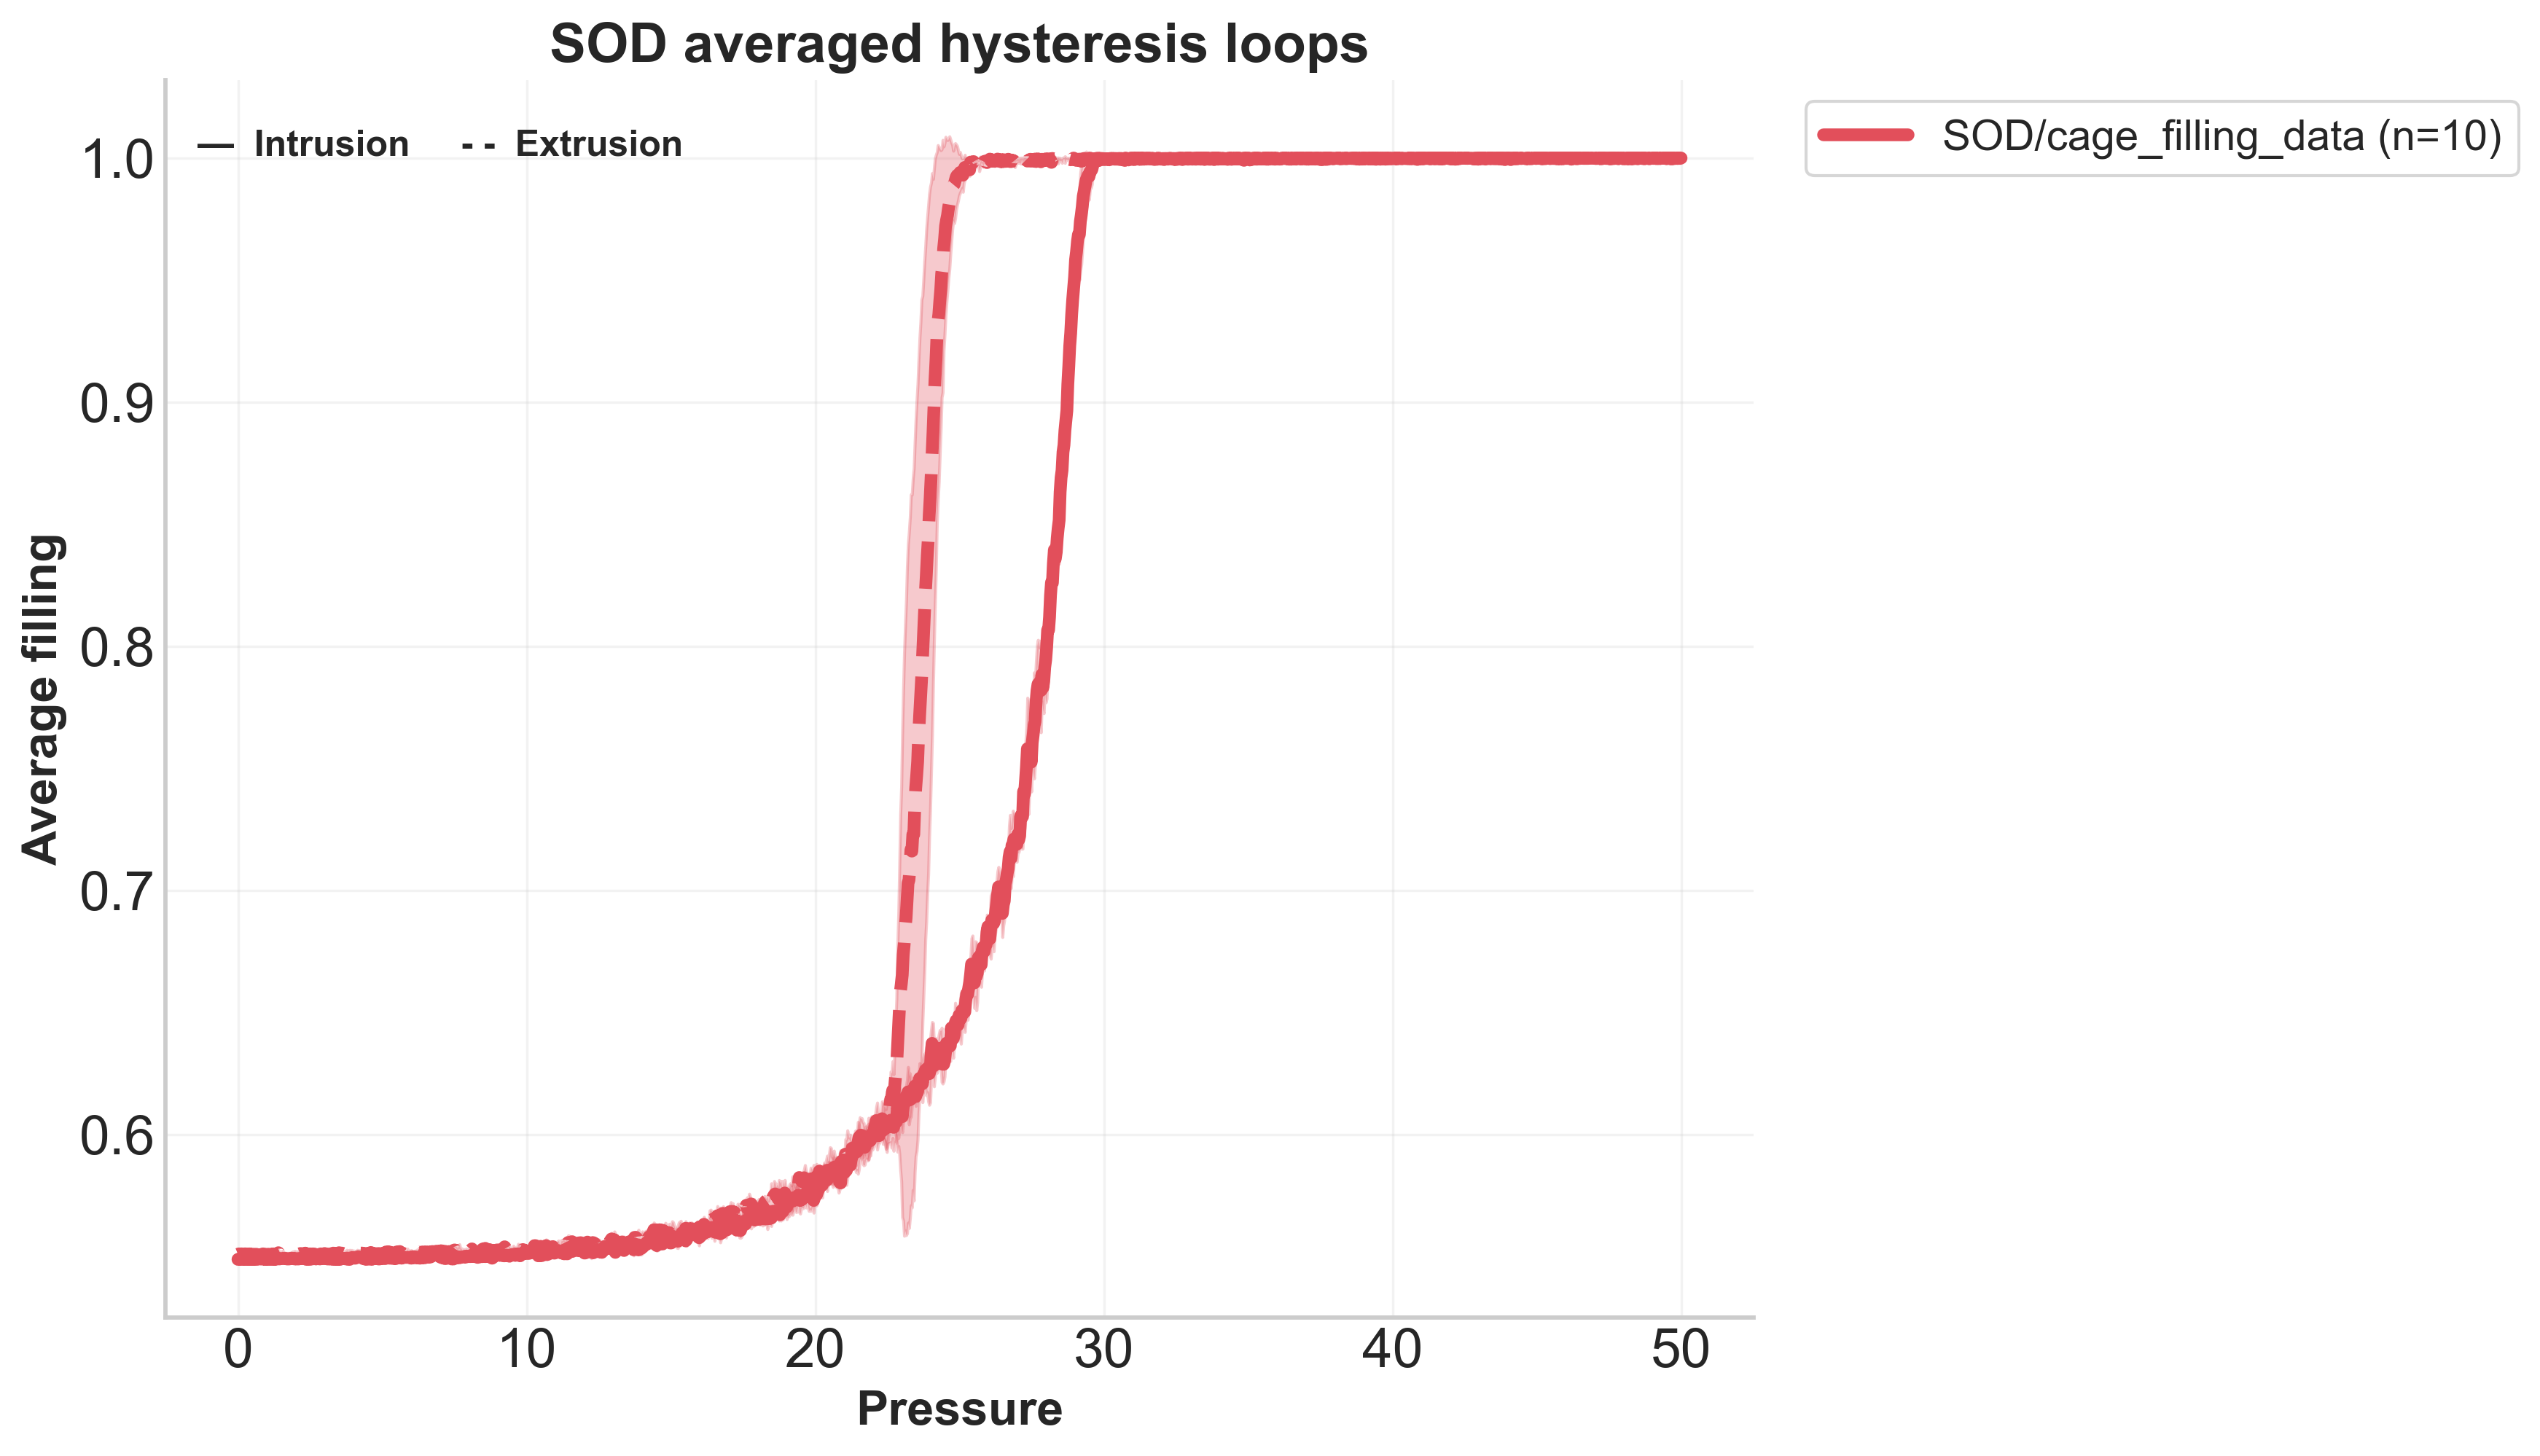

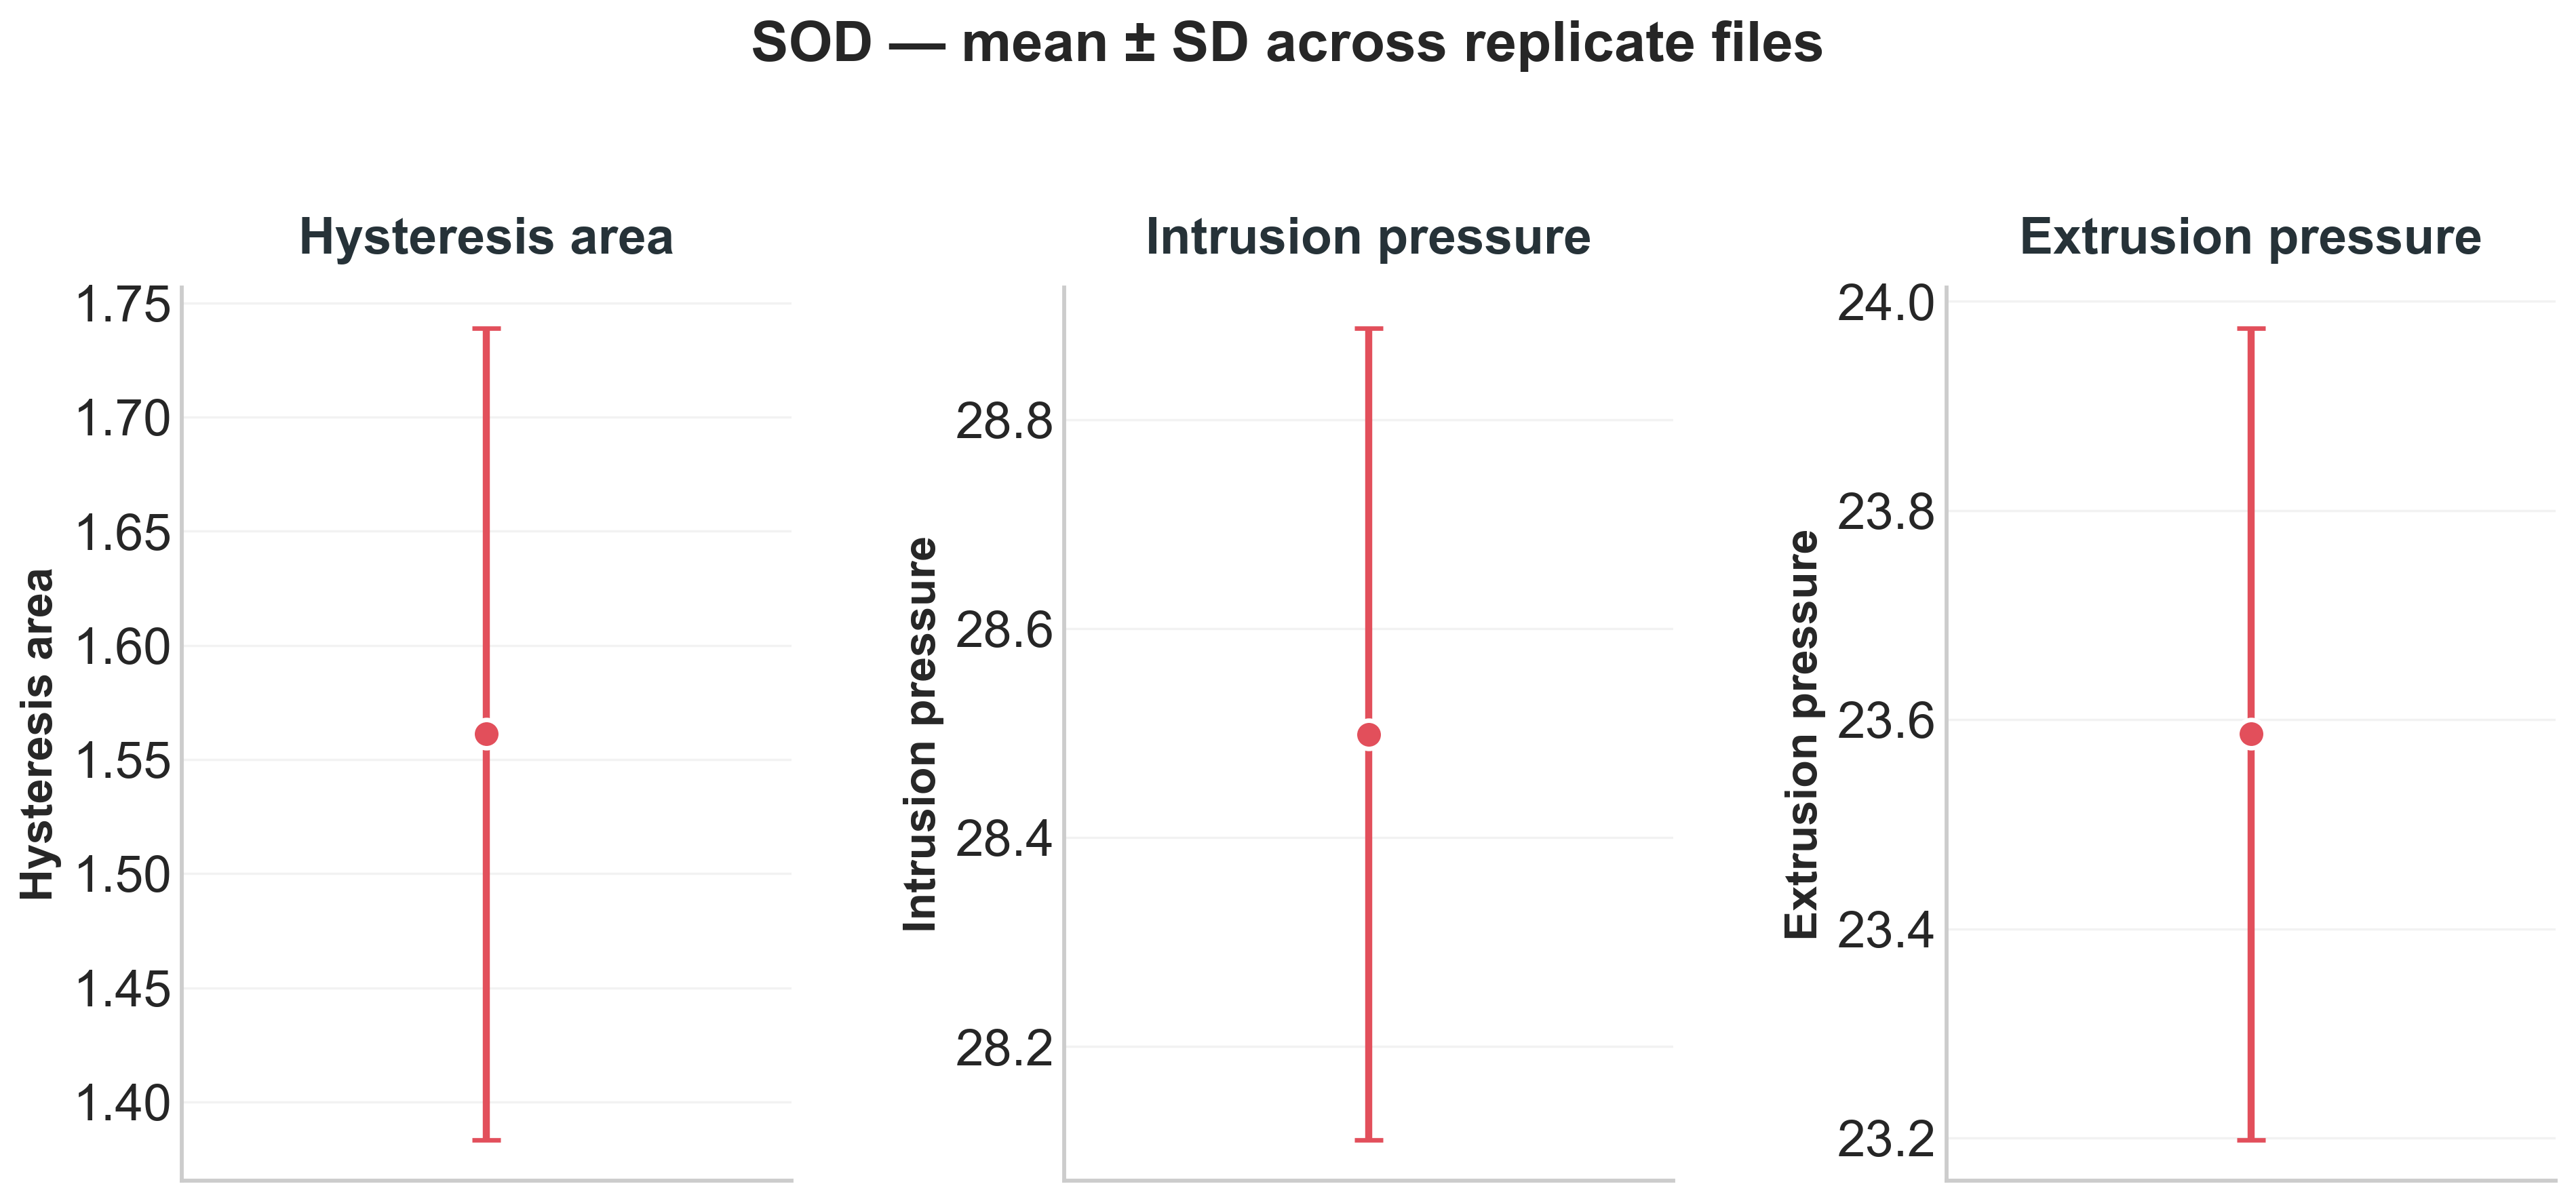

In [4]:
# To plot only selected cases, replace None with a list from sod_groups.keys().
SOD_SELECTED_GROUPS = None
if sod_groups:
    sod_loop_fig, _ = plot_averaged_loops(
        sod_groups, 'SOD averaged hysteresis loops', SOD_SELECTED_GROUPS
    )
    sod_loop_fig.savefig(FIGURE_DIR / 'SOD_hysteresis_loops.png',
                         dpi=300, bbox_inches='tight', facecolor='white')
sod_metric_result = plot_metric_summary(sod_summary, 'SOD')
if sod_metric_result is not None:
    sod_metric_fig, _ = sod_metric_result
    sod_metric_fig.savefig(FIGURE_DIR / 'SOD_metrics_summary.png',
                           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [5]:
if not sod_summary.empty:
    sod_summary.to_csv('SOD_analysis_summary.csv', index=False)
    sod_replicates.to_csv('SOD_analysis_replicates.csv', index=False)

# Part 2 — RHO topology

RHO results are processed independently, using the same definitions and plots so the two topologies can be compared consistently.

In [6]:
rho_groups = discover_groups(RHO_ROOTS, patterns=['**/filling*.csv', '**/cage_filling_data*.csv'])
print(f'RHO groups: {len(rho_groups)}; files: {sum(map(len, rho_groups.values()))}')
for group, files in rho_groups.items():
    print(f'{len(files):3d}  {group}')

rho_replicates, rho_summary = analyse_groups(rho_groups)
display(rho_summary)

Skipping missing folder: results_zif71_sensitivity
RHO groups: 1; files: 10
 10  RHO/cage_filling_data


,Group,N_Files,N_Unique_Results,Hysteresis_Mean,Hysteresis_SD,Intrusion_Pressure_Mean,Intrusion_Pressure_SD,Extrusion_Pressure_Mean,Extrusion_Pressure_SD
0,RHO/cage_filling_data,10,10,8.056845,1.19734,67.373145,0.501977,35.377045,3.958341


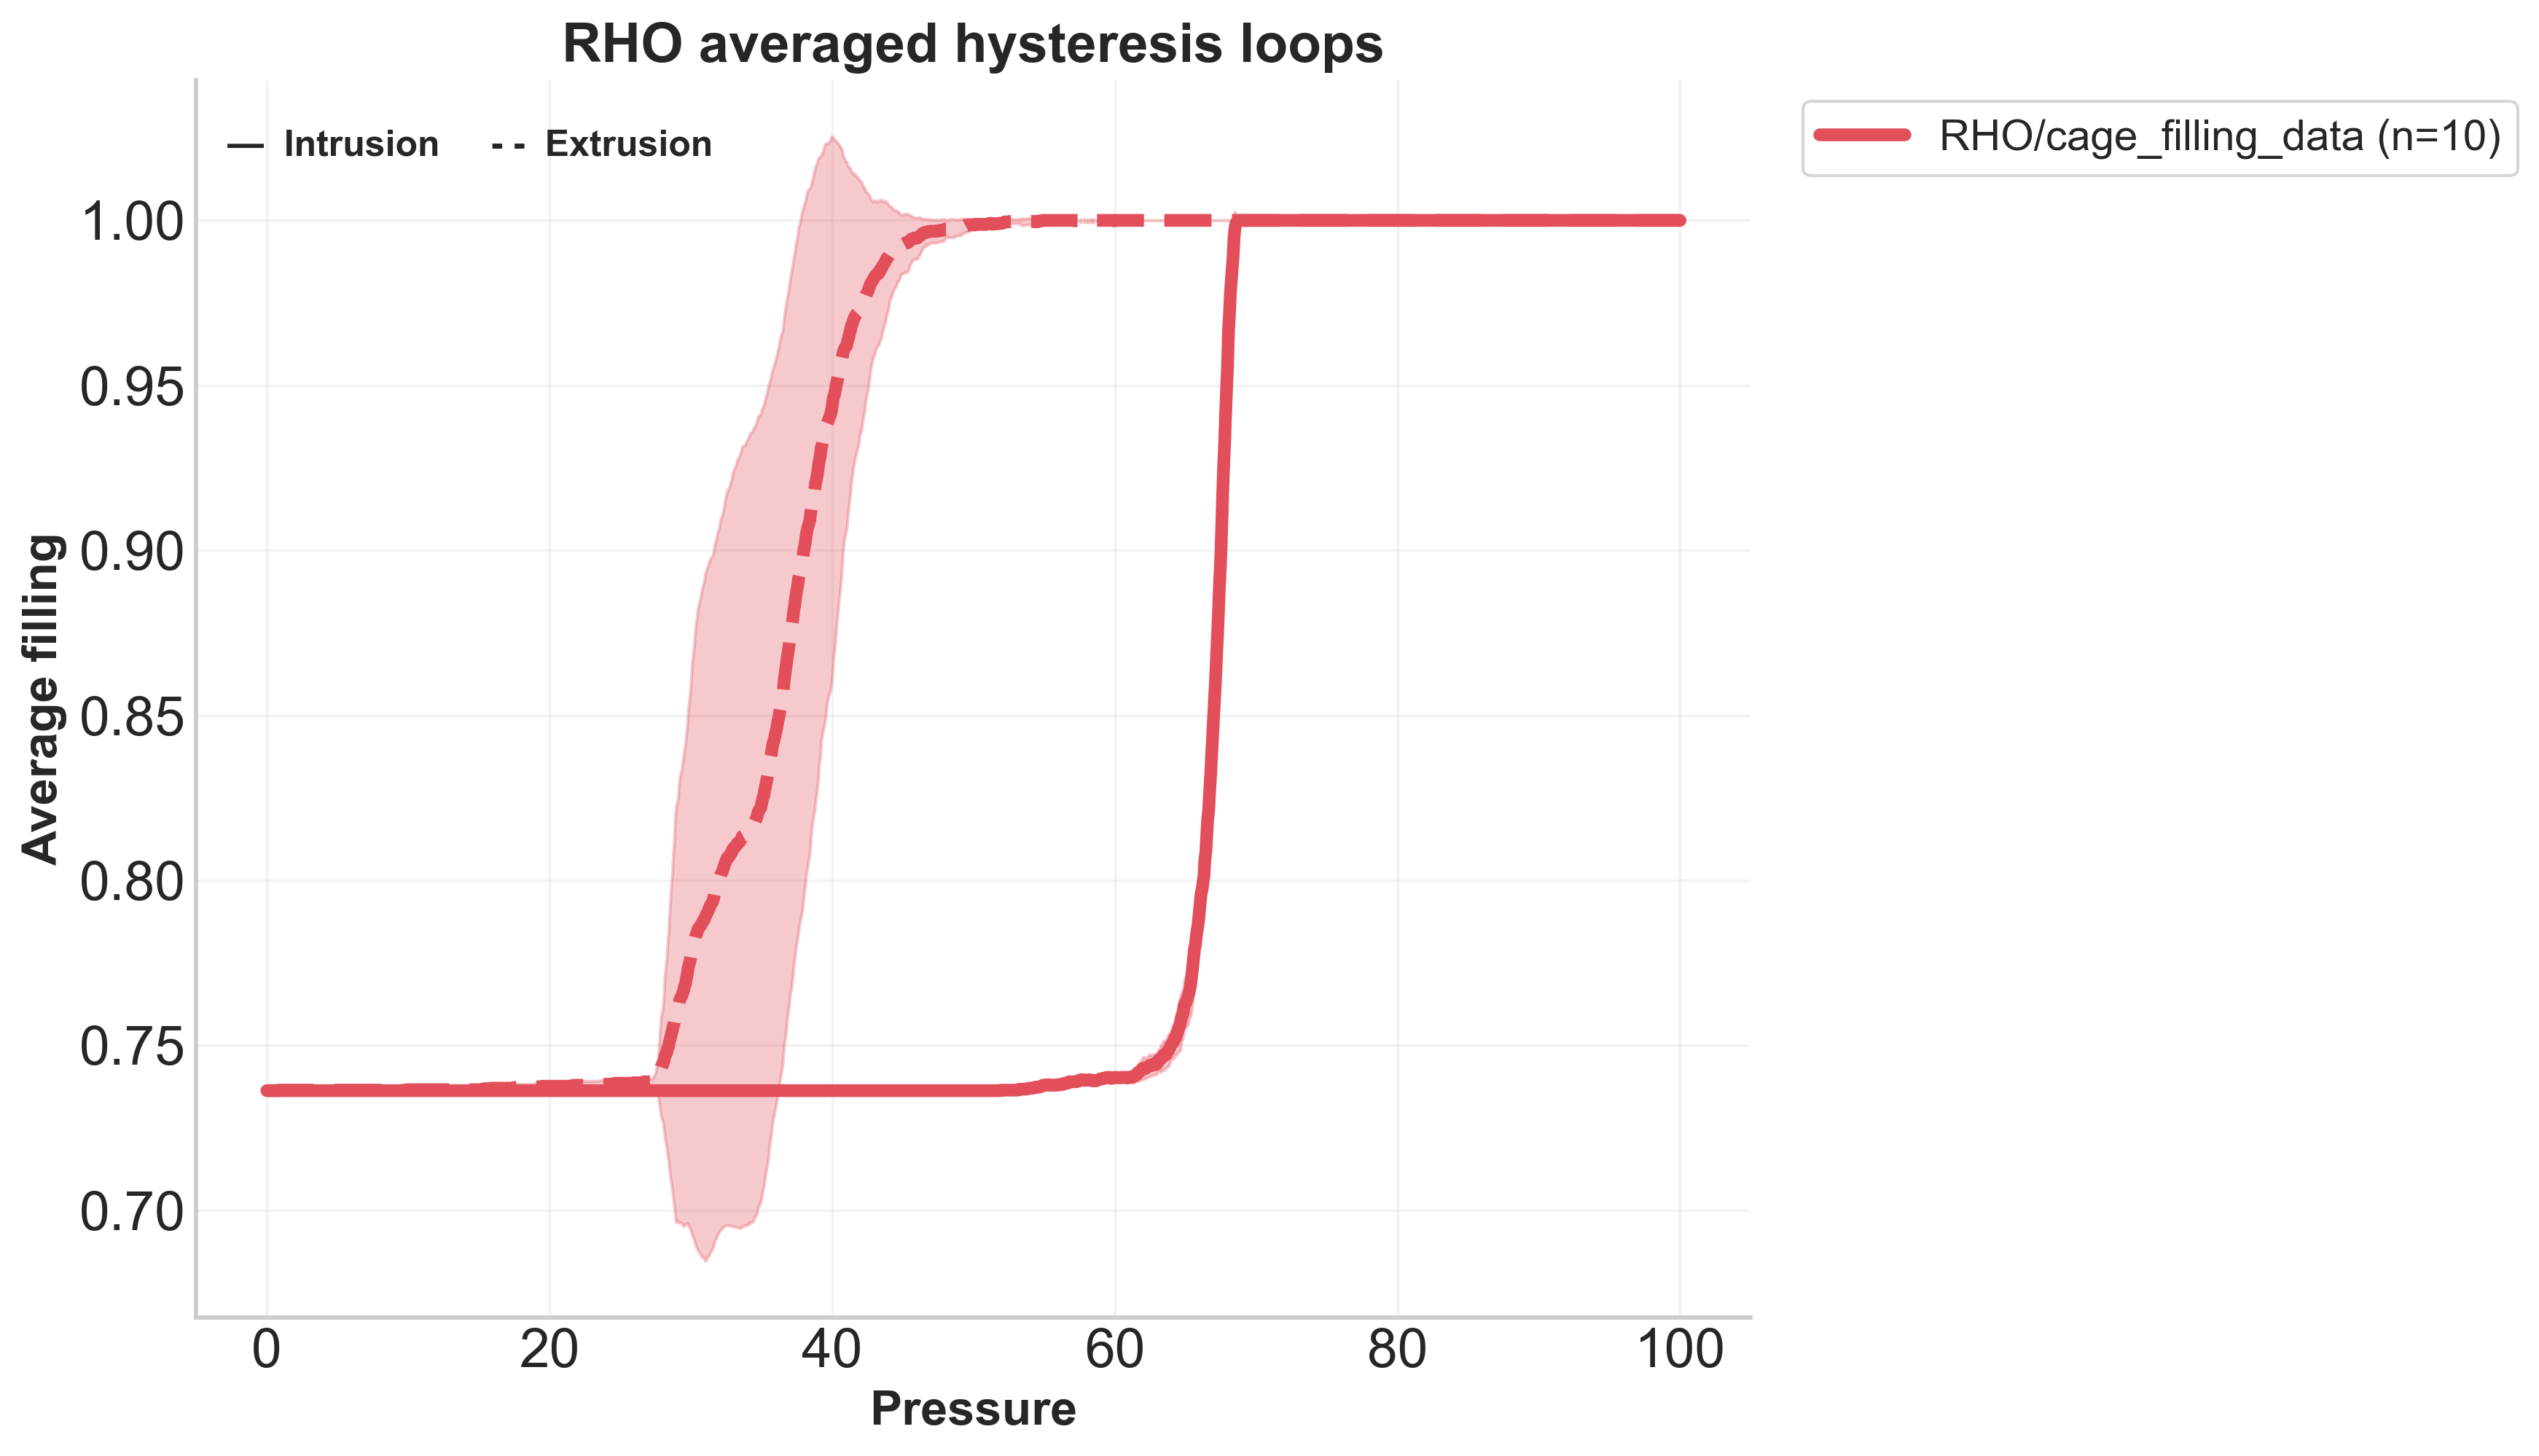

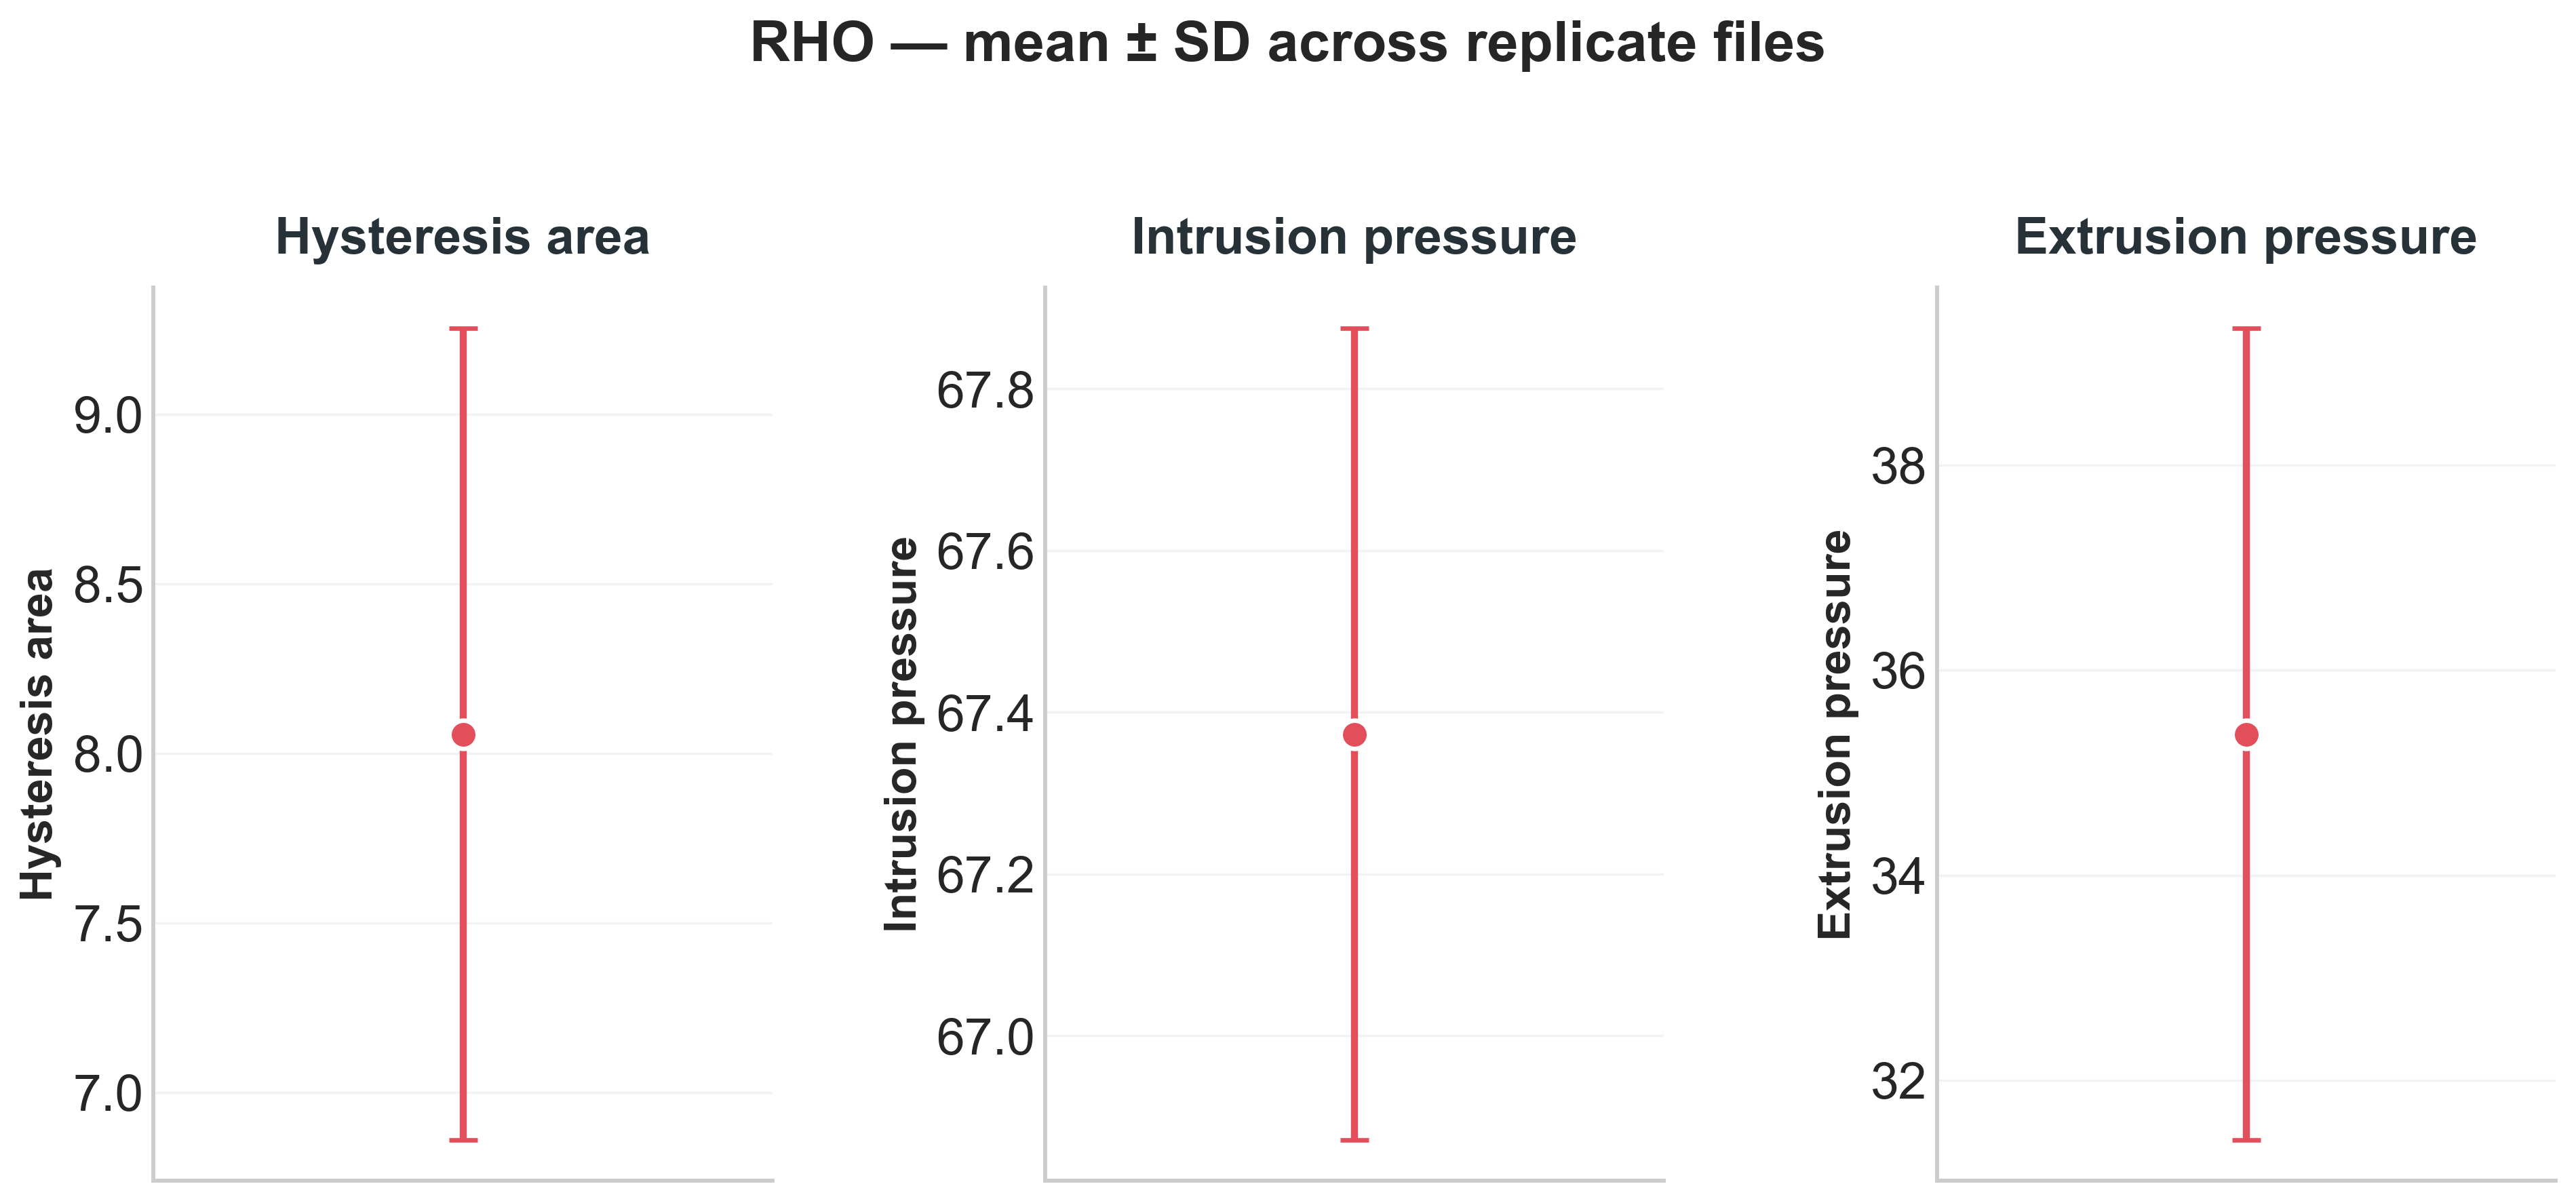

In [7]:
# To plot only selected cases, replace None with a list from rho_groups.keys().
RHO_SELECTED_GROUPS = None
if rho_groups:
    rho_loop_fig, _ = plot_averaged_loops(
        rho_groups, 'RHO averaged hysteresis loops', RHO_SELECTED_GROUPS
    )
    rho_loop_fig.savefig(FIGURE_DIR / 'RHO_hysteresis_loops.png',
                         dpi=300, bbox_inches='tight', facecolor='white')
rho_metric_result = plot_metric_summary(rho_summary, 'RHO')
if rho_metric_result is not None:
    rho_metric_fig, _ = rho_metric_result
    rho_metric_fig.savefig(FIGURE_DIR / 'RHO_metrics_summary.png',
                           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [8]:
if not rho_summary.empty:
    rho_summary.to_csv('RHO_analysis_summary.csv', index=False)
    rho_replicates.to_csv('RHO_analysis_replicates.csv', index=False)